## Halfyearly Distributions throughout election periods

- Are the cycle time distributions always the same in the 5 year election periods? - compare cycle time distributions over the 5 years - maybe difficult laws are always tackled in the beginning - could be compared to assumed distributions

In [85]:
%load_ext autoreload
%autoreload 2
import pm4py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import constants
import pandas as pd

# TODO - all this should go to helper and constants files!
def generate_passed_bill_column(df):
    df["is_passed_bill"] = df.groupby("case:concept:name")["concept:name"].transform(lambda x: x.isin(possible_passed_bills_activities).any())
    return df
def generate_end_date_column(df):
    df["endDate"] = (
        df.groupby("case:concept:name")["time:timestamp"]
        .transform("max")
    )
    return df


passed_bills_activities_berlin = ['Gesetz- und Verordnungsblatt', 'Bekanntmachung (Gesetz- und Verordnungsblatt)']
passed_bills_activities_bawue = ["Gesetz", "Gesetzblatt für Baden-Württemberg"]
passed_bills_activities_brandenburg = ["Gesetz", "Gesetz- und Verordnungsblatt"]

possible_passed_bills_activities = passed_bills_activities_berlin + passed_bills_activities_bawue + passed_bills_activities_brandenburg


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [86]:
berlin_df_full_timeframe = pm4py.read_xes("./data-xes/Berlin-with-topics-and-agreement-scores-all-time.xes")
berlin_df_full_timeframe = generate_passed_bill_column(berlin_df_full_timeframe)
berlin_df_full_timeframe = generate_end_date_column(berlin_df_full_timeframe)
# Calculate cycle time per case and broadcast to all rows in the case
berlin_df_full_timeframe['cycle_time'] = berlin_df_full_timeframe.groupby('case:concept:name')["time:timestamp"].transform(lambda x: x.max() - x.min())
berlin_df_full_timeframe_grouped = berlin_df_full_timeframe.groupby("case:concept:name").first().reset_index()

parsing log, completed traces ::   0%|          | 0/1813 [00:00<?, ?it/s]

In [87]:
bawue_df_full_timeframe = pm4py.read_xes("./data-xes/Baden-Württemberg-with-topics-and-agreement-scores-all-time-preprocessed.xes")
bawue_df_full_timeframe = generate_passed_bill_column(bawue_df_full_timeframe)
bawue_df_full_timeframe = generate_end_date_column(bawue_df_full_timeframe)
# Calculate cycle time per case and broadcast to all rows in the case
bawue_df_full_timeframe['cycle_time'] = bawue_df_full_timeframe.groupby('case:concept:name')["time:timestamp"].transform(lambda x: x.max() - x.min())
bawue_df_full_timeframe_grouped = bawue_df_full_timeframe.groupby("case:concept:name").first().reset_index()

parsing log, completed traces ::   0%|          | 0/1465 [00:00<?, ?it/s]

In [88]:
brandenburg_df_full_timeframe = pm4py.read_xes("./data-xes/Brandenburg-with-topics-and-agreement-scores-all-time-preprocessed.xes")
brandenburg_df_full_timeframe = generate_passed_bill_column(brandenburg_df_full_timeframe)
brandenburg_df_full_timeframe = generate_end_date_column(brandenburg_df_full_timeframe)
# Calculate cycle time per case and broadcast to all rows in the case
brandenburg_df_full_timeframe['cycle_time'] = brandenburg_df_full_timeframe.groupby('case:concept:name')["time:timestamp"].transform(lambda x: x.max() - x.min())
brandenburg_df_full_timeframe_grouped = brandenburg_df_full_timeframe.groupby("case:concept:name").first().reset_index()

parsing log, completed traces ::   0%|          | 0/1410 [00:00<?, ?it/s]

In [89]:
def getCycleTimeDistributionPerElectionPeriod(df_grouped, electionPeriodStartDates, coalitionsSorted, maxY=600):
    # for each separate part of the dataframe (always the data before the startDate of the next election period)
    # calculate cycle time average (mean or median) per month in that time
    # plot in a basic line plot with a dot per month

    for i in range(len(electionPeriodStartDates)): 

        print(f"\n\n-------------------ELECTION PERIOD {coalitionsSorted[i][0]}-------------------")
        print(f"Government during this election period: {coalitionsSorted[i][1]['government']}")
        print(f"Opposition during this election period: {coalitionsSorted[i][1]['opposition']}")

        # get data for the election period (from startDate to startDate of next election period or now if it is the last one)
        startDate = pd.to_datetime(electionPeriodStartDates[i], dayfirst=True, utc=True)
        endDate = pd.to_datetime(electionPeriodStartDates[i+1], dayfirst=True, utc=True) if i < len(electionPeriodStartDates)-1 else pd.Timestamp.now(tz='UTC')
        
        electionPeriod = df_grouped[(df_grouped['DokDat'] >= startDate) & (df_grouped["endDate"] < endDate)]
        #print(f"Processing election period {i}: {startDate} to {endDate}")
        #print(f"Number of rows in this election period: {len(electionPeriod)}")

        electionPeriod = electionPeriod.copy()

        electionPeriod["cycle_time_seconds"] = (
            electionPeriod["cycle_time"].dt.total_seconds()
        )


        electionPeriod["half_year"] = (
            electionPeriod["DokDat"].dt.year.astype(str)
            + "-H"
            + (((electionPeriod["DokDat"].dt.month - 1) // 6) + 1).astype(str)
        )

        # quarters
        #electionPeriod["half_year"] = (
        #    electionPeriod["DokDat"]
        #        .dt.tz_localize(None)
        #        .dt.to_period("Q")
        #)

        # calculate cycle time per month
        #electionPeriod['cycle_time_seconds'] = electionPeriod['cycle_time'].dt.total_seconds()
        #electionPeriod['month'] = electionPeriod['DokDat'].dt.to_period('M')
        cycle_time_per_half_year = electionPeriod.groupby('half_year')['cycle_time_seconds'].mean() / 60/60/24 # convert to days //TODO: or median?
        frequency_per_half_year = electionPeriod.groupby('half_year').size()
        #print(f"Cycle time per half-year for election period {i}:\n{cycle_time_per_half_year}")

        # plot this absolute numbers
        fig, ax1 = plt.subplots(figsize=(10, 5))
        # First y-axis (Cycle Time)
        ax1.plot(
            cycle_time_per_half_year.index.astype(str),
            cycle_time_per_half_year.values,
            marker='o',
            label="Average Cycle Time (days)"
        )
        ax1.set_ylabel("Average Cycle Time (days)")
        ax1.set_ylim(0, maxY)  # keep consistent across election periods
        ax1.set_xlabel("Half-years")

        # Second y-axis (Frequency)
        ax2 = ax1.twinx()
        ax2.plot(
            frequency_per_half_year.index.astype(str),
            frequency_per_half_year.values,
            marker='x',
            linestyle='--',
            color='orange',
            label="Frequency"
        )
        ax2.set_ylabel("Frequency")

        plt.title(f"Cycle Time Distribution for Election Period {i}")

        ax1.tick_params(axis='x', rotation=45)

        # Combine legends
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
        plt.tight_layout()
        plt.show()

'''
print("---------------------------BERLIN-------------------------------")
getCycleTimeDistributionPerElectionPeriod(berlin_df_full_timeframe_grouped, constants.BERLIN_ELECTION_PERIODS_START_DATES, constants.BERLIN_COALITIONS_SORTED)

print("---------------------------BAWUE-------------------------------")
getCycleTimeDistributionPerElectionPeriod(bawue_df_full_timeframe_grouped, constants.BAWUE_ELECTION_PERIODS_START_DATES, constants.BADEN_WUERTTEMBERG_COALITIONS_SORTED, maxY=400)

print("---------------------------BRANDENBURG-------------------------------")
getCycleTimeDistributionPerElectionPeriod(brandenburg_df_full_timeframe_grouped, constants.BRANDENBURG_ELECTION_PERIODS_START_DATES, constants.BRANDENBURG_COALITIONS_SORTED, maxY=400)
'''


'\nprint("---------------------------BERLIN-------------------------------")\ngetCycleTimeDistributionPerElectionPeriod(berlin_df_full_timeframe_grouped, constants.BERLIN_ELECTION_PERIODS_START_DATES, constants.BERLIN_COALITIONS_SORTED)\n\nprint("---------------------------BAWUE-------------------------------")\ngetCycleTimeDistributionPerElectionPeriod(bawue_df_full_timeframe_grouped, constants.BAWUE_ELECTION_PERIODS_START_DATES, constants.BADEN_WUERTTEMBERG_COALITIONS_SORTED, maxY=400)\n\nprint("---------------------------BRANDENBURG-------------------------------")\ngetCycleTimeDistributionPerElectionPeriod(brandenburg_df_full_timeframe_grouped, constants.BRANDENBURG_ELECTION_PERIODS_START_DATES, constants.BRANDENBURG_COALITIONS_SORTED, maxY=400)\n'

In [116]:
custom_colors = [
"#d73027",
"#f46d43",
"#fdae61",
"#fee090",
"#ffffbf",
"#e0f3f8",
"#abd9e9",
"#74add1",
"#4575b4"
]

custom_colors = [
    "#ffffd9",
    "#edf8b1",
    "#c7e9b4",
    "#7fcdbb",
    "#41b6c4",
    "#1d91c0",
    "#225ea8",
    "#253494",
    "#081d58",
]



custom_colors = [
    "#8c510a",
    "#bf812d",
    "#dfc27d",
    "#f6e8c3",
    "#f5f5f5",
    "#c7eae5",
    "#80cdc1",
    "#35978f",
    "#01665e"
]

custom_colors = ['#deebf7','#deebf7','#c6dbef','#9ecae1','#6baed6','#4292c6','#2171b5','#08519c','#08306b']

cmap = LinearSegmentedColormap.from_list("custom_diverging", custom_colors)

marker_map = {
    1: "X",    # 1-party coalition
    2: "o",   # 2-party coalition
    3: "^",   # 3-party coalition
    "SPD": "o",
    "CDU": "X",
    "GRÜNE": "^",
    "DIE LINKE": "D",
    "FDP": "s",
    "AfD": "P",
    "aligned": "o",
    "cross_ideological": "X"
}


def plotValuesHalfyearlyPerElectionPeriod(
    df_grouped,
    electionPeriodStartDates,
    coalitionsSorted,
    maxY=600,
    valueColumnName="cycle_time",
    ylabel_name="Mean cycle time (days)",
    aggregation="mean",
    marker_value=""
):
    
    
    n_periods = len(electionPeriodStartDates)
    colors = cmap(np.linspace(0, 1, n_periods))

    fig, ax = plt.subplots(figsize=(12, 4))

    n_periods = len(electionPeriodStartDates)

    for i in range(n_periods):

        startDate = pd.to_datetime(electionPeriodStartDates[i], dayfirst=True, utc=True)
        endDate = (
            pd.to_datetime(electionPeriodStartDates[i+1], dayfirst=True, utc=True)
            if i < n_periods-1
            else pd.Timestamp.now(tz='UTC')
        )

        electionPeriod = df_grouped[
            (df_grouped['DokDat'] >= startDate) &
            (df_grouped["endDate"] < endDate)
        ].copy()

        if electionPeriod.empty:
            continue

        
        if valueColumnName == "cycle_time":
            electionPeriod["cycle_time_days"] = (
                electionPeriod["cycle_time"].dt.total_seconds() / 60 / 60 / 24
            )

        months_since_start = (
            (electionPeriod["DokDat"].dt.year - startDate.year) * 12 +
            (electionPeriod["DokDat"].dt.month - startDate.month)
        )

        electionPeriod["half_year_index"] = months_since_start // 6

        if valueColumnName == "cycle_time":
            y_column_value_per_half_year = (
                electionPeriod
                .groupby("half_year_index")["cycle_time_days"]
                .mean()
                .sort_index()
            )
        elif valueColumnName == "government_agreement_score" or valueColumnName == "opposition_agreement_score":
            if aggregation == "mean":
                y_column_value_per_half_year = (
                electionPeriod
                .groupby("half_year_index")[valueColumnName]
                .mean()
                .sort_index()
                )
            elif aggregation == "count":
                y_column_value_per_half_year = (
                    electionPeriod
                    .groupby("half_year_index")[valueColumnName]
                    .apply(lambda x: (x == 1).sum() / len(x))
                    .sort_index()
                )

        if len(y_column_value_per_half_year) < 2:
            continue

        x_numeric = y_column_value_per_half_year.index.values
        y = y_column_value_per_half_year.values
        x_labels = [f"H{int(i)+1}" for i in x_numeric]


        # include coalition size as marker
        if marker_value == "coalition_size":
            marker_map_value = len(coalitionsSorted[i][1]["government"])
            label = f"{coalitionsSorted[i][0].date()} ({marker_map_value} parties)"

        if marker_value == "first_party":
            marker_map_value = coalitionsSorted[i][1]["government"][0]
            label = f"{coalitionsSorted[i][0].date()} ({marker_map_value}) as gov party"

        if marker_value == "coalition_type":
            marker_map_value = coalitionsSorted[i][1]["coalition_type"]
            label = f"{coalitionsSorted[i][0].date()} ({marker_map_value} coalition)"

        label = f"{coalitionsSorted[i][0].date()}"
        marker = "x"
        if marker_value != "":
            marker = marker_map[marker_map_value]

        # Plot actual values with gradient color
        line, = ax.plot(
            x_labels,
            y,
            marker = marker,
            markersize=8,
            #markeredgecolor="black",
            #markeredgewidth=0.5,
            color=colors[i],
            label=label
        )

        # Trend line (same tone)
        coeffs = np.polyfit(x_numeric, y, 1)
        trend = np.poly1d(coeffs)

        ax.plot(
            x_labels,
            trend(x_numeric),
            linestyle="--",
            color=colors[i],
            alpha=0.9
        )


        # TODO: normalize these slopes so that I can compare them across the parliaments  
        #print(f"{coalitionsSorted[i][0]} slope: {coeffs[0]:.2f} days per half-year")

    ax.set_ylabel(ylabel_name, fontsize=14)
    ax.set_xlabel("Half-years since start of election period", fontsize=14)
    ax.set_ylim(0, maxY)
    #ax.set_title("Value Development per Election Period (Older → Lighter Blue)")
    ax.legend(title="Election period",
            loc="upper left",
            bbox_to_anchor=(1, 1),
            fontsize=14)
    ax.tick_params(axis='x', rotation=45, labelsize=14)
    ax.tick_params(axis='y', labelsize=14)

    plt.tight_layout()
    plt.show()

## Mean cylce times all traces

---------------------------BERLIN-------------------------------


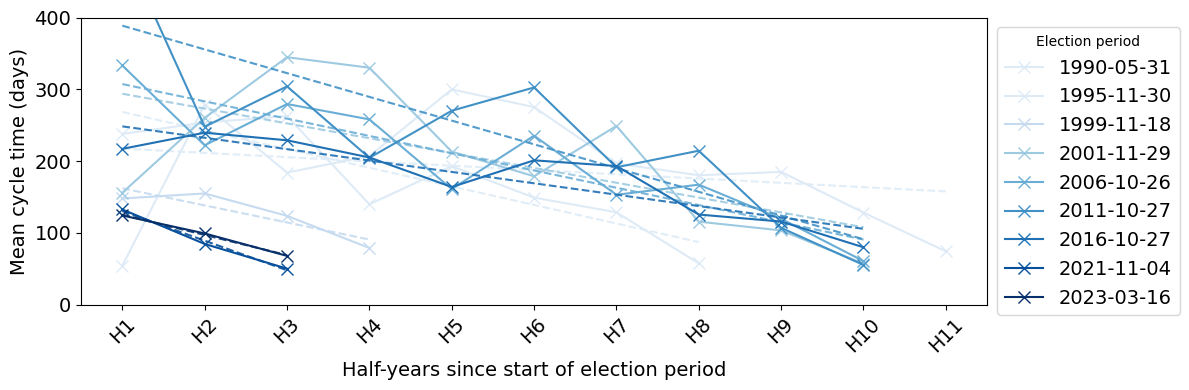

---------------------------BAWUE-------------------------------


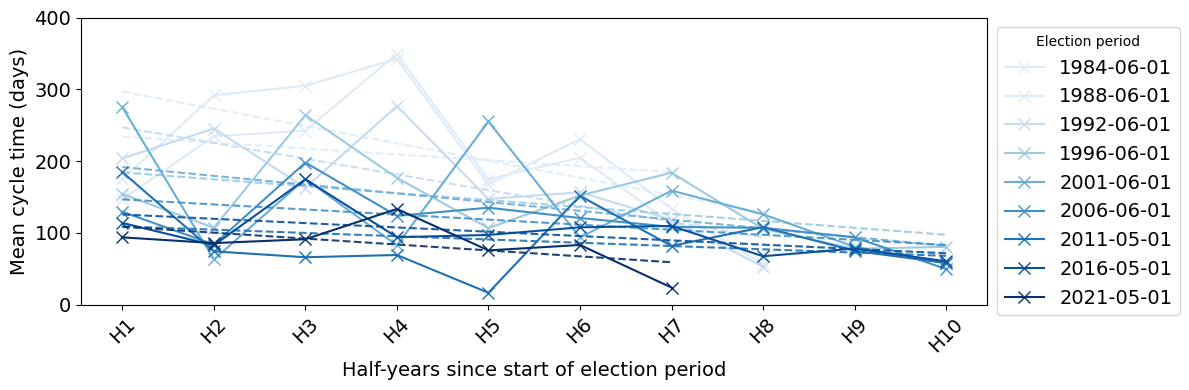

---------------------------BRANDENBURG-------------------------------


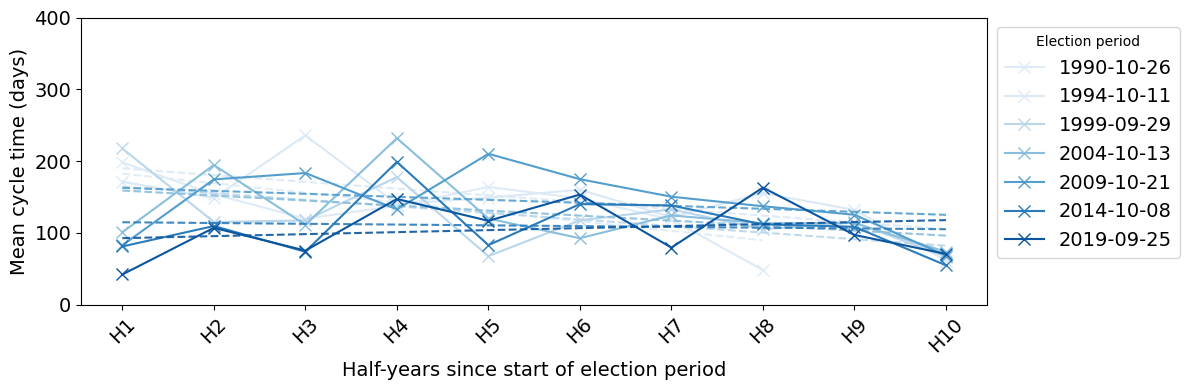

In [117]:
#markerValue="coalition_type"
#markerValue="coalition_size"
#markerValue="first_party"
markerValue=""

print("---------------------------BERLIN-------------------------------")
plotValuesHalfyearlyPerElectionPeriod(berlin_df_full_timeframe_grouped, constants.BERLIN_ELECTION_PERIODS_START_DATES, constants.BERLIN_COALITIONS_SORTED, maxY=400, marker_value=markerValue)

print("---------------------------BAWUE-------------------------------")
plotValuesHalfyearlyPerElectionPeriod(bawue_df_full_timeframe_grouped, constants.BAWUE_ELECTION_PERIODS_START_DATES, constants.BADEN_WUERTTEMBERG_COALITIONS_SORTED, maxY=400, marker_value=markerValue)

print("---------------------------BRANDENBURG-------------------------------")
plotValuesHalfyearlyPerElectionPeriod(brandenburg_df_full_timeframe_grouped, constants.BRANDENBURG_ELECTION_PERIODS_START_DATES, constants.BRANDENBURG_COALITIONS_SORTED, maxY=400, marker_value=markerValue)


## Traces with full government agreement per half year per election period

---------------------------BERLIN-------------------------------


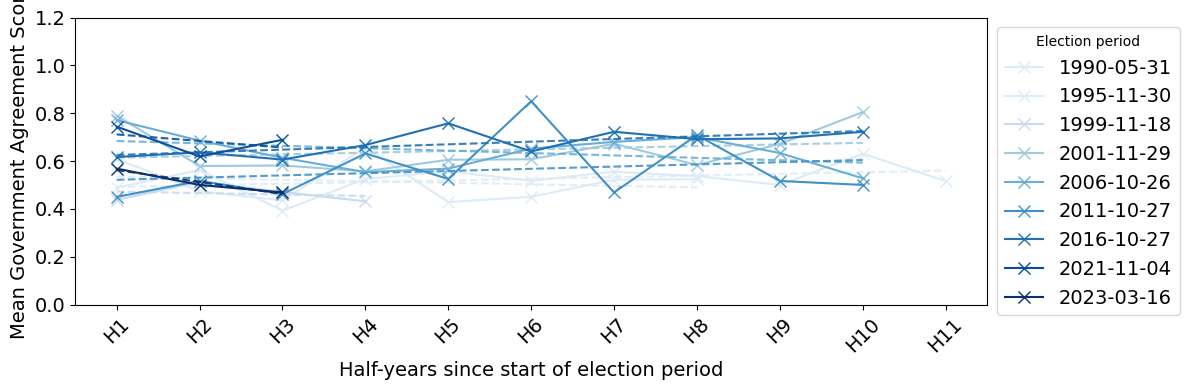

---------------------------BAWUE-------------------------------


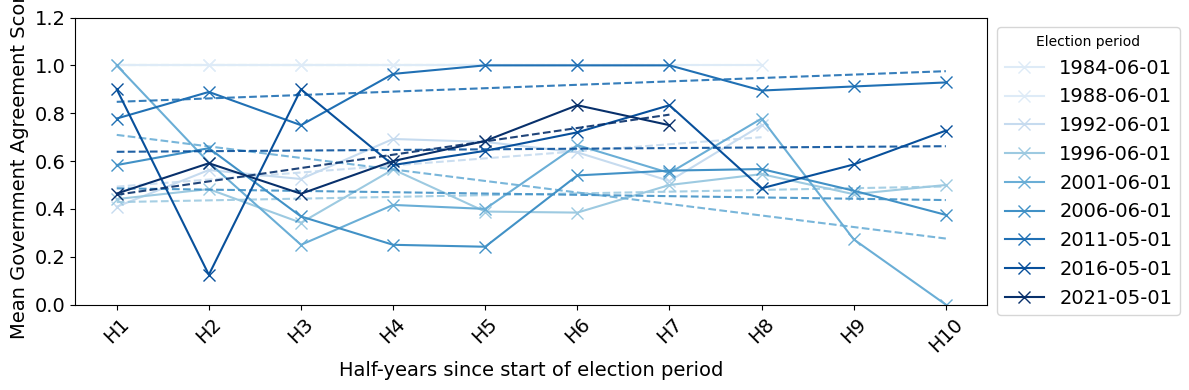

---------------------------BRANDENBURG-------------------------------


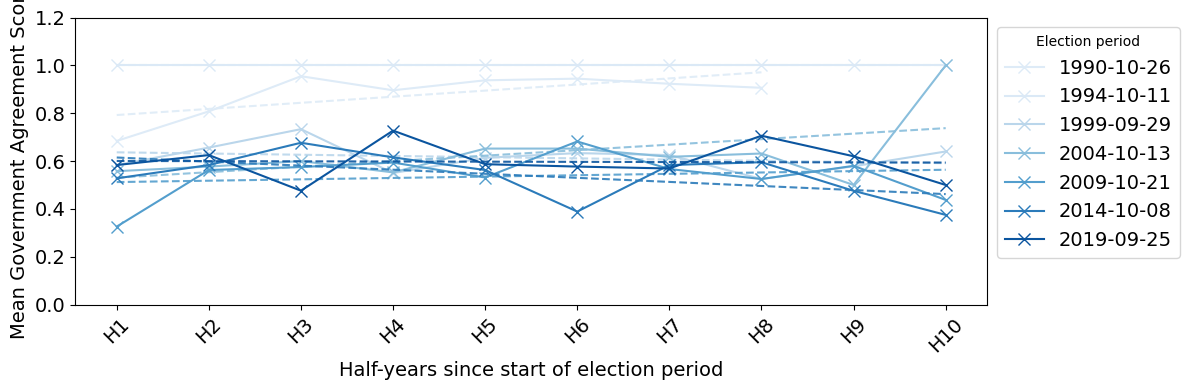

In [118]:
print("---------------------------BERLIN-------------------------------")
plotValuesHalfyearlyPerElectionPeriod(berlin_df_full_timeframe_grouped, constants.BERLIN_ELECTION_PERIODS_START_DATES, constants.BERLIN_COALITIONS_SORTED, maxY=1.2, valueColumnName="government_agreement_score", ylabel_name="Mean Government Agreement Score", marker_value=markerValue)

print("---------------------------BAWUE-------------------------------")
plotValuesHalfyearlyPerElectionPeriod(bawue_df_full_timeframe_grouped, constants.BAWUE_ELECTION_PERIODS_START_DATES, constants.BADEN_WUERTTEMBERG_COALITIONS_SORTED, maxY=1.2, valueColumnName="government_agreement_score", ylabel_name="Mean Government Agreement Score", marker_value=markerValue)

print("---------------------------BRANDENBURG-------------------------------")
plotValuesHalfyearlyPerElectionPeriod(brandenburg_df_full_timeframe_grouped, constants.BRANDENBURG_ELECTION_PERIODS_START_DATES, constants.BRANDENBURG_COALITIONS_SORTED, maxY=1.2, valueColumnName="government_agreement_score", ylabel_name="Mean Government Agreement Score", marker_value=markerValue)


### Count of full agreement traces per half-year

---------------------------BERLIN-------------------------------


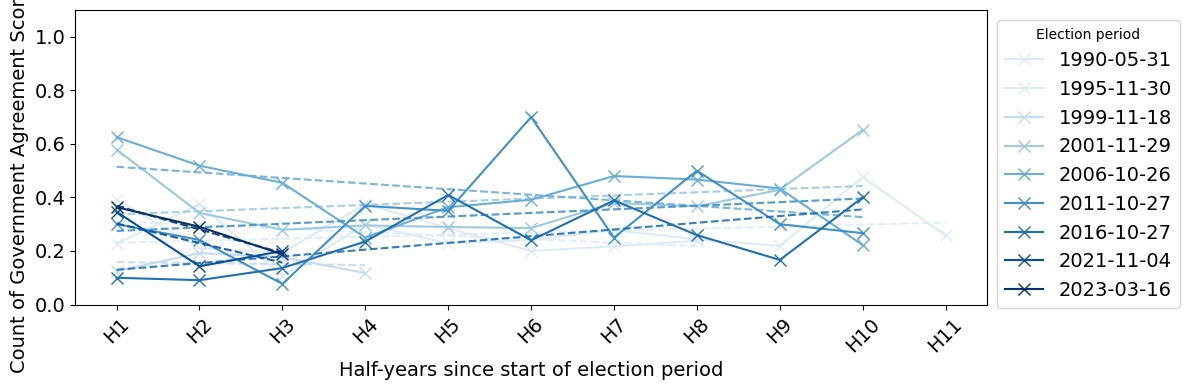

---------------------------BAWUE-------------------------------


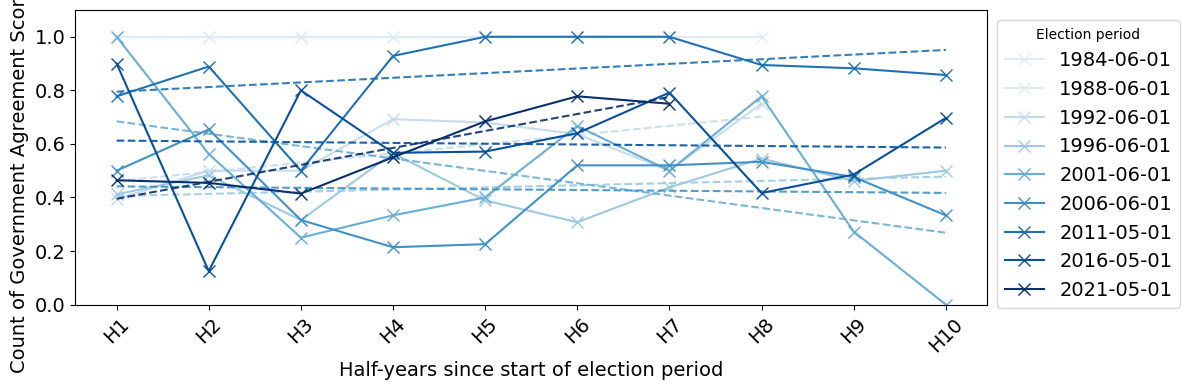

---------------------------BRANDENBURG-------------------------------


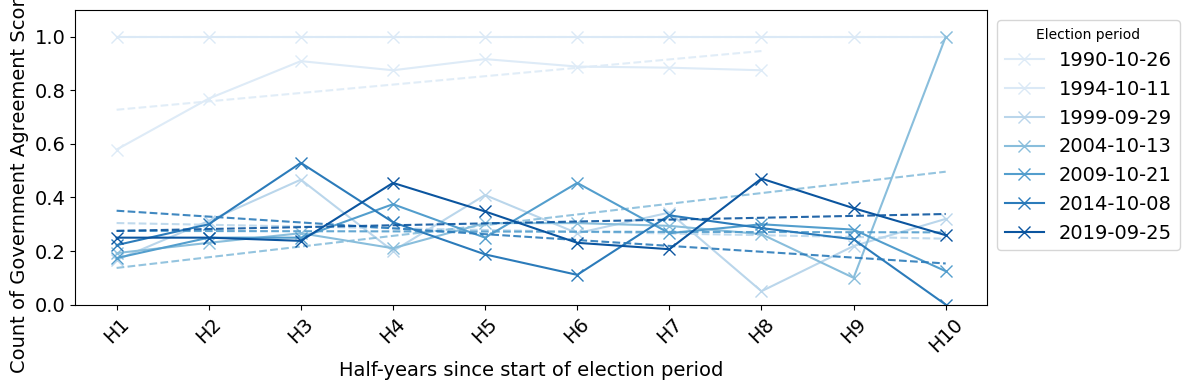

In [119]:
print("---------------------------BERLIN-------------------------------")
plotValuesHalfyearlyPerElectionPeriod(berlin_df_full_timeframe_grouped, 
                                      constants.BERLIN_ELECTION_PERIODS_START_DATES, 
                                      constants.BERLIN_COALITIONS_SORTED, 
                                      maxY=1.1, 
                                      valueColumnName="government_agreement_score", 
                                      ylabel_name="Count of Government Agreement Score==1", 
                                      aggregation="count",
                                      marker_value=markerValue)

print("---------------------------BAWUE-------------------------------")
plotValuesHalfyearlyPerElectionPeriod(bawue_df_full_timeframe_grouped, 
                                      constants.BAWUE_ELECTION_PERIODS_START_DATES, 
                                      constants.BADEN_WUERTTEMBERG_COALITIONS_SORTED, 
                                      maxY=1.1, 
                                      valueColumnName="government_agreement_score", 
                                      ylabel_name="Count of Government Agreement Score==1", 
                                      aggregation="count",
                                      marker_value=markerValue)

print("---------------------------BRANDENBURG-------------------------------")
plotValuesHalfyearlyPerElectionPeriod(brandenburg_df_full_timeframe_grouped, 
                                      constants.BRANDENBURG_ELECTION_PERIODS_START_DATES, 
                                      constants.BRANDENBURG_COALITIONS_SORTED, 
                                      maxY=1.1, 
                                      valueColumnName="government_agreement_score", 
                                      ylabel_name="Count of Government Agreement Score==1", 
                                      aggregation="count",
                                      marker_value=markerValue)


## Boxplots per electionperiod

In [120]:
def plotCycleTimeBoxplotsPerElectionPeriod(
    df_grouped,
    electionPeriodStartDates,
    coalitionsSorted,
    ylabel_name="Cycle Time (days)",
    maxY=None
):
    n_periods = len(electionPeriodStartDates)

    # Use same colormap logic as before
    colors = cmap(np.linspace(0, 1, n_periods))

    boxplot_data = []
    labels = []

    for i in range(n_periods):

        startDate = pd.to_datetime(electionPeriodStartDates[i], dayfirst=True, utc=True)
        endDate = (
            pd.to_datetime(electionPeriodStartDates[i+1], dayfirst=True, utc=True)
            if i < n_periods - 1
            else pd.Timestamp.now(tz='UTC')
        )

        electionPeriod = df_grouped[
            (df_grouped['DokDat'] >= startDate) &
            (df_grouped["endDate"] < endDate)
        ].copy()

        if electionPeriod.empty:
            continue

        # Convert cycle time to days
        cycle_time_days = (
            electionPeriod["cycle_time"].dt.total_seconds() / 60 / 60 / 24
        ).dropna()

        if len(cycle_time_days) == 0:
            continue

        boxplot_data.append(cycle_time_days.values)

        # Label: year + coalition size (optional but useful)
        coalition_size = len(coalitionsSorted[i][1]["government"])
        coalition_type = coalitionsSorted[i][1]["coalition_type"]
        first_party = coalitionsSorted[i][1]["government"][0]
        
        label = f"{startDate.year} ({coalition_size}P - {coalition_type} - {first_party})"
        labels.append(label)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(12, 6))

    bp = ax.boxplot(
        boxplot_data,
        patch_artist=True,   # allows coloring
        showfliers=True
    )

    # Apply colors to each box
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    # Optional: style lines
    for median in bp['medians']:
        median.set_color("black")
        median.set_linewidth(1.5)

    # Axis settings
    ax.set_xticklabels(labels, rotation=45)
    ax.set_ylabel(ylabel_name)
    ax.set_xlabel("Election Period")
    ax.set_title("Distribution of Cycle Times per Election Period")

    if maxY is not None:
        ax.set_ylim(0, maxY)

    plt.tight_layout()
    plt.show()


---------------------------BERLIN-------------------------------


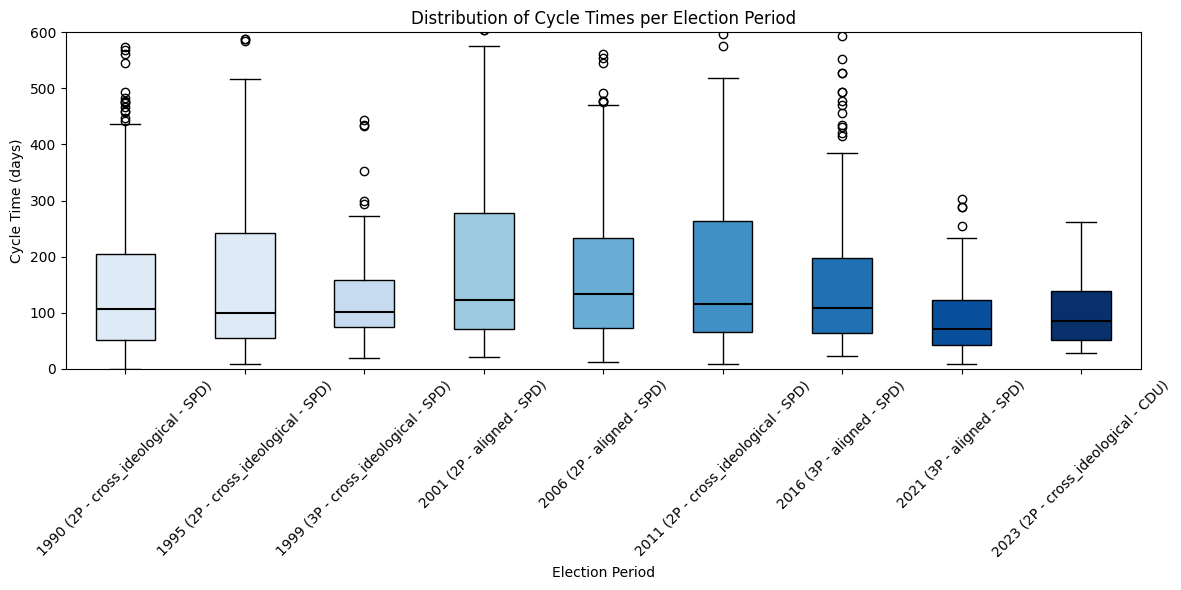

---------------------------BAWUE-------------------------------


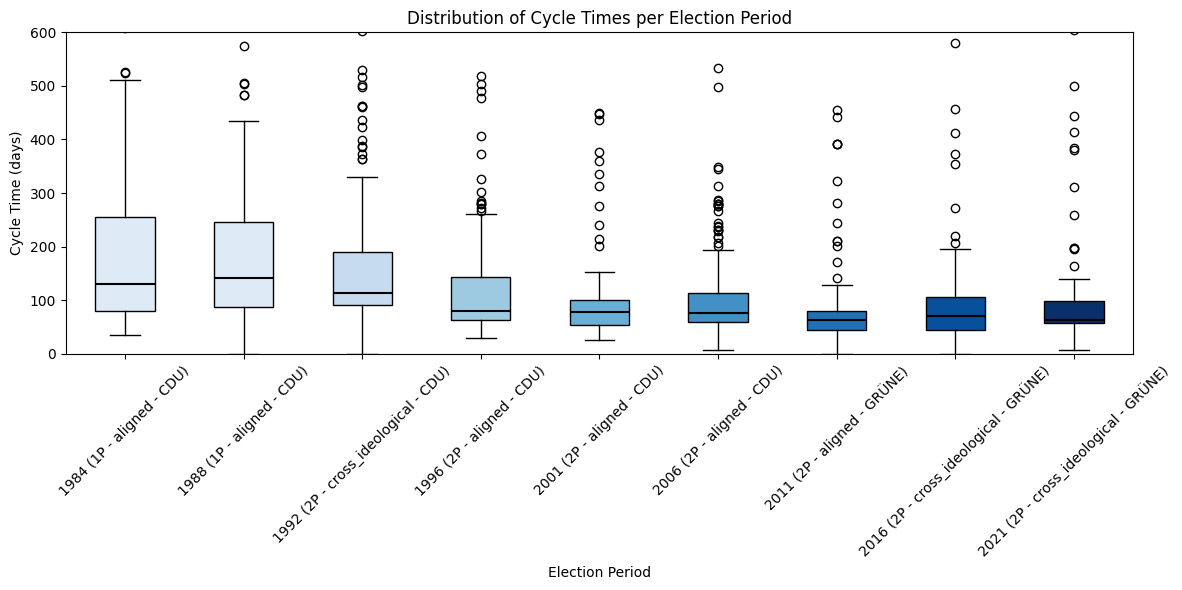

---------------------------BRANDENBURG-------------------------------


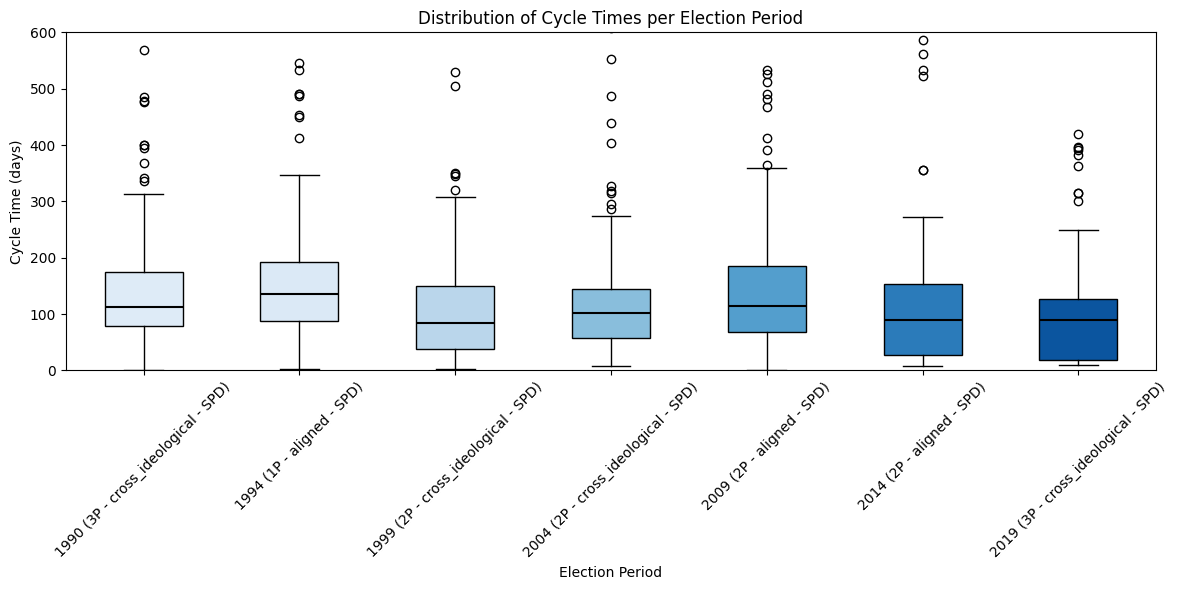

In [121]:
print("---------------------------BERLIN-------------------------------")
plotCycleTimeBoxplotsPerElectionPeriod(
    df_grouped=berlin_df_full_timeframe_grouped,
    electionPeriodStartDates=constants.BERLIN_ELECTION_PERIODS_START_DATES,
    coalitionsSorted=constants.BERLIN_COALITIONS_SORTED,
    ylabel_name="Cycle Time (days)",
    maxY=600
)

print("---------------------------BAWUE-------------------------------")
plotCycleTimeBoxplotsPerElectionPeriod(
    df_grouped=bawue_df_full_timeframe_grouped,
    electionPeriodStartDates=constants.BAWUE_ELECTION_PERIODS_START_DATES,
    coalitionsSorted=constants.BADEN_WUERTTEMBERG_COALITIONS_SORTED,
    ylabel_name="Cycle Time (days)",
    maxY=600
)

print("---------------------------BRANDENBURG-------------------------------")
plotCycleTimeBoxplotsPerElectionPeriod(
    df_grouped=brandenburg_df_full_timeframe_grouped,
    electionPeriodStartDates=constants.BRANDENBURG_ELECTION_PERIODS_START_DATES,
    coalitionsSorted=constants.BRANDENBURG_COALITIONS_SORTED,
    ylabel_name="Cycle Time (days)",
    maxY=600
)